In [13]:
from utils import *
from DRAG import *
from FAPT import * 

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from tqdm.auto import tqdm

sigma = 1.0
tg = 200.0

s = Simulation()

wd_ref, A_ref = compute_cos_params(s, tg)

Ar_ref = float(np.real(A_ref))
Ai_ref = float(np.imag(A_ref))

# Absolute Grenzen des dargestellten Parameterbereichs
wd_min = float(wd_ref - 0.01)
wd_max = float(wd_ref + 0.01)

Ar_min = float(Ar_ref - 0.05)
Ar_max = float(Ar_ref + 0.05)

Ai_min = float(Ai_ref - 0.01)
Ai_max = float(Ai_ref + 0.01)

wd_values = np.linspace(wd_min, wd_max, 51)
Ar_values = np.linspace(Ar_min, Ar_max, 51)
Ai_values = np.linspace(Ai_min, Ai_max, 15)

print(f"wd range:    [{wd_min:.6f}, {wd_max:.6f}]")
print(f"Re(A) range: [{Ar_min:.6f}, {Ar_max:.6f}]")
print(f"Im(A) range: [{Ai_min:.6f}, {Ai_max:.6f}]")

resonances = dict(s.resonances) if not isinstance(s.resonances, dict) else s.resonances
E = np.asarray(s.E_array)
V_posHarm = np.asarray(s.V1_dressed_array)

V0 = getattr(s, "V0", None)
ref_state = getattr(s, "ref_state", None)

H_ab_full3 = np.zeros((len(Ai_values), len(Ar_values), len(wd_values)), dtype=complex)
H_bc_full3 = np.zeros_like(H_ab_full3)

progress = tqdm(total=len(Ai_values) * len(Ar_values) * len(wd_values), desc="Floquet scan up to order 3")

for iAi, Ai in enumerate(Ai_values):
    for iAr, Ar in enumerate(Ar_values):
        A = Ar + 1j * Ai
        V_full = V_from_Vtilde(V_posHarm, A=A, analytics=False)

        for iwd, wd in enumerate(wd_values):
            H_ab_full3[iAi, iAr, iwd] = Heff_Floquet_summed(3, s.state_a, s.state_b, wd, resonances, E, V_full, V0=V0, ref_state=ref_state, analytics=False)
            H_bc_full3[iAi, iAr, iwd] = Heff_Floquet_summed(3, s.state_b, s.state_c, wd, resonances, E, V_full, V0=V0, ref_state=ref_state, analytics=False)

            progress.update(1)

progress.close()

# Vollständiges Verhältnis aller komplex addierten Beiträge bis Ordnung 3:
#
# lambda_<=3 = |H_ab^(<=3)| / |H_bc^(<=3)|
#
# mit H_ij^(<=3) = H_ij^(1) + H_ij^(2) + H_ij^(3)

lambda_full3 = np.full(H_ab_full3.shape, np.nan, dtype=float)
np.divide(np.abs(H_ab_full3), np.abs(H_bc_full3), out=lambda_full3, where=np.abs(H_bc_full3) > 1e-14)

iwd_ref = np.argmin(np.abs(wd_values - wd_ref))
iAr_ref = np.argmin(np.abs(Ar_values - Ar_ref))
iAi_ref = np.argmin(np.abs(Ai_values - Ai_ref))

lambda_ref = lambda_full3[iAi_ref, iAr_ref, iwd_ref]

# Prozentuale Abweichung von lambda am Referenzpunkt
lambda_deviation = 100.0 * np.abs(lambda_full3 / lambda_ref - 1.0)

# Größte Abweichung über den untersuchten Bereich von Im(A)
lambda_deviation_worst = np.nanmax(lambda_deviation, axis=0)

max_lambda_deviation = np.nanmax(lambda_deviation_worst)

print(f"lambda_ref:             {lambda_ref:.10g}")
print(f"maximum lambda change:  {max_lambda_deviation:.6g} %")

wd range:    [4.432960, 4.452960]
Re(A) range: [0.688722, 0.788722]
Im(A) range: [-0.010000, 0.010000]


Floquet scan up to order 3:   0%|          | 0/39015 [00:00<?, ?it/s]

lambda_ref:             0.1001950552
maximum lambda change:  0.0582116 %


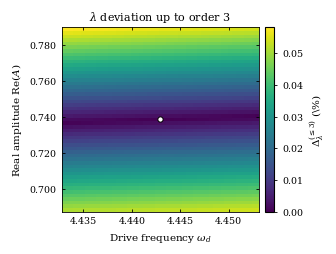

In [16]:
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "font.size": 7.5,
    "axes.labelsize": 7.5,
    "axes.titlesize": 8.0,
    "xtick.labelsize": 6.8,
    "ytick.labelsize": 6.8,
})

fig, ax = plt.subplots(figsize=(3.25, 2.45))

color_max = max(max_lambda_deviation, 1e-14)

image = ax.pcolormesh(wd_values, Ar_values, lambda_deviation_worst, shading="auto", cmap="viridis", vmin=0.0, vmax=color_max, rasterized=True)

ax.plot(wd_ref, Ar_ref, marker="o", markersize=3.8, markerfacecolor="white", markeredgecolor="black", markeredgewidth=0.7)

ax.set_title(r"$\lambda$ deviation up to order 3", pad=5)
ax.set_xlabel(r"Drive frequency $\omega_d$")
ax.set_ylabel(r"Real amplitude $\operatorname{Re}(A)$")

ax.xaxis.set_major_formatter(FormatStrFormatter("%.3f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

ax.tick_params(direction="in", top=True, right=True, width=0.6, length=2.5)

for spine in ax.spines.values():
    spine.set_linewidth(0.6)

colorbar = fig.colorbar(image, ax=ax, pad=0.025, fraction=0.055)
colorbar.set_label(r"$\Delta_{\lambda}^{(\leq 3)}$ (\%)", labelpad=4)
colorbar.ax.tick_params(labelsize=6.8, width=0.6, length=2.5)

fig.tight_layout(pad=0.5)
fig.savefig("Figure/floquet_lambda_deviation_order3.pdf", dpi=600, bbox_inches="tight")

plt.show()